## Non Linear Mooring Line forces 
Heavily based on Workshop 2: Offset calculation and theory.

**IMPORTANT**: Download the required external functions and put them in the same folder as this notebook <br>
https://github.com/rdeke/ComModHOS_double/blob/main/book/Module7/StringDynamicForces.py <br>
https://github.com/rdeke/ComModHOS_double/blob/main/book/Module7/StringForcesAndStiffness.py

In this code the static equilibrium position of a string from a given external load on the buoy is calculated.
We consider a spar buoy in beam waves of width 20m in 320m of water depth. The fairleads connecting the mooring lines to the spar buoy are located 70m below the surface. The external constant second order wave drift load is taken in 4m waves. We use a 9cm diameter cable.

In [44]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit

# Spar buoy and sea properties
H = 320-70 # from fairleads to seabed
B_buoy = 4.7*2 # buoy diameter
H_signif = 4 #significant wave height (change for assignment!)
g = 9.81
rho_w = 1025

# Cable properties
d_anchor = 0.09 #9cm cable diameter
L = 902.2 #Cable sailing given
line_density = 77.7066  #cable mass per unit length
E_steel = 210e9


### Part 1: Theoretical line shape

From these basic values we can deduce some other needed values. 
Firstly the second order wave drift foce can be determined, for the whole exposed length of the ship
The cross-sectional area of the cable can be used to calculate the density of the cable, which in turn yeilds the cable weight in water.

In [45]:
## Deduced values
F_d = (0.5*rho_w*g*(H_signif/2)**2)*B_buoy # Second order wave drift force
print("Drift force = ", F_d/10**3, "kN")

# Deduced cable values
A_anchor = np.pi*(d_anchor/2)**2 #cross-section surface area
rho_steel = line_density/A_anchor   #accurate cable density
weight = A_anchor*(rho_steel-rho_w)*g # General cable, kN/m

print("Rho steel - ",rho_steel, 'kg/m3')
print("Cable weight in water = ", weight, 'kN/m')

Drift force =  189.0387 kN
Rho steel -  12214.705679866345 kg/m3
Cable weight in water =  698.3330094517323 kN/m


We now plot the mooring line shapes on the ship. Remember that for beam waves (coming from the side) we need to look at the ship from the front or the back to see the excursion.

986.1
828.33


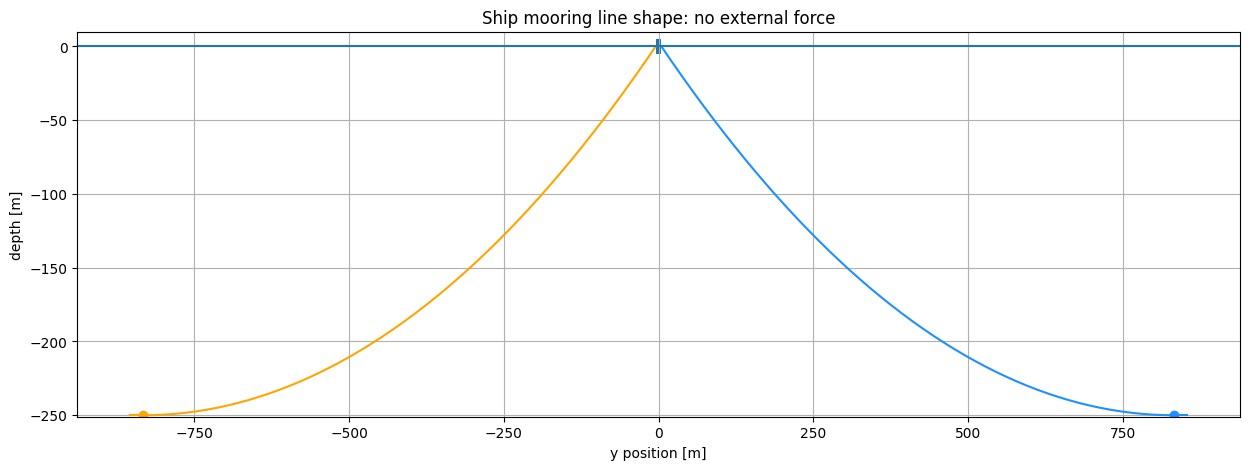

In [46]:
def xtotsolve(Fx, Stot, w, h, xtot):
    Stot = Stot
    S = Fx/w * np.sinh(np.arccosh(h*w/Fx + 1))
    xmax = Fx/w * np.arccosh(h*w/Fx + 1)
    return Stot - S + xmax - xtot

w = weight
h = H
Stot =  L

R_anchor = 853.87 # Given anchoring positions from center of buoy
xtot = R_anchor
Fx = fsolve(xtotsolve, x0=1, args=(Stot, w, h, xtot))[0]
print(round(Fx/1000,2))

def zline(Fx, w, x, h):
    return Fx/w * (np.cosh(w/Fx*x) - 1) - h

xmax = Fx/w * np.arccosh(h*w/Fx + 1)
ymax = R_anchor
print(round(xmax,2))
x = np.linspace(0,xmax)
xpositive = x[::-1]
x1 = np.linspace(B_buoy/2, xmax+B_buoy/2)
x2 = np.linspace(xmax+B_buoy/2,ymax)

z1 = zline(Fx,w,xpositive,h)
z2 = [-h for i in range(len(x2))]

plt.figure(figsize=(15,5))
plt.plot(x1,z1, c="dodgerblue")
plt.plot(x2,z2, c="dodgerblue")
plt.plot(-x1[::-1],z1[::-1], c= "orange")
plt.plot(-x2[::-1],z2[::-1], c= "orange")
plt.plot(xmax+B_buoy/2,-h,'o', c="dodgerblue")
plt.plot(-xmax-B_buoy/2,-h,'o', c="orange")
plt.xlabel("y position [m]")
plt.ylabel("depth [m]")
plt.title(f"Ship mooring line shape: no external force") #, {Fx/1000:.0f} kN mooring line force")
plt.xlim((-1.1*ymax, 1.1*ymax))
plt.ylim((-h-1,10))
plt.plot([-1.1*ymax, 1.1*ymax],[0,0])
plt.grid()
plt.fill_between([-B_buoy/2,-B_buoy/2, B_buoy/2, B_buoy/2, -B_buoy/2], [-5, 5, 5, -5, -5]);

2.2 1087.4 897.7 -1.0


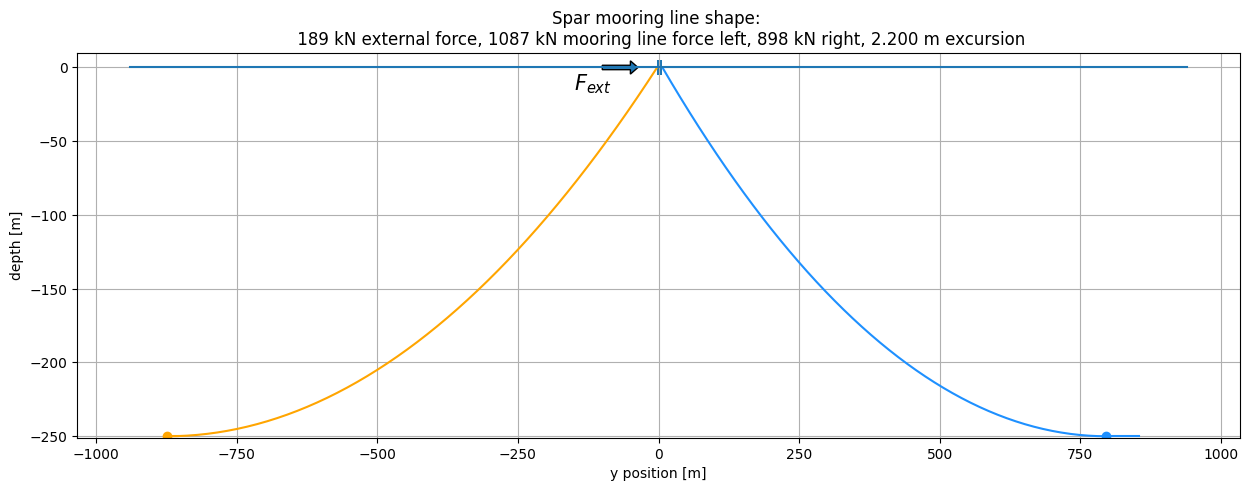

In [47]:
# With external force: left add excursion, untill Fl = Fr+Fext
Fext = F_d

# Initial values
error = 10
xpos = 0
step = 10**(-2)
xtot = R_anchor
while error > 0.01:
    xtotl = xtot + xpos
    xtotr = xtot - xpos
    Fxl = fsolve(xtotsolve, x0=1, args=(Stot, w, h, xtotl))[0]
    Fxr = fsolve(xtotsolve, x0=1, args=(Stot, w, h, xtotr))[0]
    error = Fxr + Fext - Fxl
    xpos += step
print(np.round(xpos-step,2), np.round(Fxl/1000,1),np.round(Fxr/1000,1), np.round(error/1000))

# Right side
xmax = Fxr/w * np.arccosh(h*w/Fxr + 1)
xtemp1 = np.linspace(0,xmax)
xtemp2 = xtemp1[::-1]
x1 = np.linspace(B_buoy/2+xpos, xmax+B_buoy/2+xpos)
x2 = np.linspace(xmax+B_buoy/2+xpos,ymax)
z1 = zline(Fxr,w,xtemp2,h)
z2 = [-h for i in range(len(x2))]
plt.figure(figsize=(15,5))
plt.plot(x1,z1, c="dodgerblue")
plt.plot(x2,z2, c="dodgerblue")
plt.plot(xmax+B_buoy/2+xpos,-h,'o', c="dodgerblue")
# Left side
xmax = Fxl/w * np.arccosh(h*w/Fxl + 1)
xtemp1 = np.linspace(0,xmax)
xtemp2 = xtemp1[::-1]
x1 = np.linspace(-B_buoy/2+xpos, -xmax-B_buoy/2+xpos)
x2 = np.linspace(-xmax-B_buoy/2+xpos,-ymax)
z1 = zline(Fxl,w,xtemp2,h)
z2 = [-h for i in range(len(x2))]
plt.plot(x1,z1, c="orange")
plt.plot(x2,z2, c="orange")
plt.plot(-xmax-B_buoy/2+xpos,-h,'o', c="orange")
# General
plt.xlabel("y position [m]")
plt.ylabel("depth [m]")
str1 = f"Spar mooring line shape: \n {Fext/1000:.0f} kN external force, {Fxl/1000:.0f} kN "
str2 = f"mooring line force left, {Fxr/1000:.0f} kN right, {xpos-step:.3f} m excursion"
plt.title(str1+str2)
# plt.xlim((-1.1*ymax, 1.1*ymax))
plt.ylim((-h-1,10))
plt.plot([-1.1*ymax, 1.1*ymax],[0,0])
plt.grid()
plt.fill_between([-B_buoy/2+xpos,-B_buoy/2+xpos, B_buoy/2+xpos, B_buoy/2+xpos, -B_buoy/2+xpos], [-5, 5, 5, -5, -5])
plt.arrow(-100, 0, 50, 0, width=3)
plt.annotate("$F_{ext}$",(-150,-15),size=15);
catoff = xpos-step # To be used later in comparison

In [48]:
print(f"Equilibrium force: {Fx/1000:.0f} kN (C and A), offset {0}")
print(f"Offset force: {Fxl/1000:.0f} kN left (C) and {Fxr/1000:.0f} kN right (A), offset {xpos-step:.2f} m")

Equilibrium force: 986 kN (C and A), offset 0
Offset force: 1087 kN left (C) and 898 kN right (A), offset 2.20 m


### Part 2: Static equilibrium using FEM

In the following cells we begin by making a function that takes the line data, including the line stiffness. In the theoretical caternary line assumption the line is assumed rigid. The function follows the same steps as in the previous tutorial:
1. Discretize the domain (here randomly taken in 31 segments)
2. Compute the initial deformation, with the option to show the "initial plot"
3. Build the system matrices
4. Let the solution converge towards the required line shape
There are some additional keyqord arguments which can be used to show intermediate results.
The function then returns the line shapes (node coordinates), as well as the horizontal force at the end of the line.

In [49]:
lmax = int(L/31)            # [m] maximum length of each string(wire) element
nElem = int(np.ceil(L/lmax))# [-] number of elements   
lElem = L/nElem             # [m] actual tensionless element size
nNode = nElem + 1           # [-] number of nodes 
print(nNode)
NodeCoord = np.zeros((nNode, 2))
Element = np.zeros((nElem, 5))

33


In [50]:
from StringForcesAndStiffness import StringForcesAndStiffness

def staticanchor(L, D, EA, m, g, TENSION_ONLY=1, initialplot=False, timeplot=False, finalplot=False):
    
    # Step 1: Discretize  ----------------------------------------------------------------------------------------------

    lmax = int(L/31)            # [m] maximum length of each string(wire) element
    nElem = int(np.ceil(L/lmax))# [-] number of elements   
    lElem = L/nElem             # [m] actual tensionless element size
    nNode = nElem + 1           # [-] number of nodes 
    NodeCoord = np.zeros((nNode, 2))
    Element = np.zeros((nElem, 5))

    for iElem in np.arange(0, nElem):
        NodeLeft = iElem
        NodeRight = iElem + 1
        NodeCoord[NodeRight] = NodeCoord[NodeLeft] + [lElem, -H/L*lElem + H ] # +H sets seabed at 0
        Element[iElem, :] = [NodeLeft, NodeRight, m, EA, lElem]
        
    # Step 2: compute initial configuration   --------------------------------------------------------------------

    nDof = 2*nNode                          # number of DOFs
    FreeDof = np.arange(0, nDof)            # free DOFs 
    FixedDof = [0,1, -2, -1]                # fixed DOFs
    FreeDof = np.delete(FreeDof, FixedDof)  # remove the fixed DOFs from the free DOFs array

    # free & fixed array indices
    fx = FreeDof[:, np.newaxis]
    fy = FreeDof[np.newaxis, :]

    SAG = 2000
    s = np.array([i[0] for i in NodeCoord])
    x = D*(s/L)
    y = -H*(s/L)-4*SAG*((x/D)-(x/D)**2)
    u = np.zeros((nDof))
    u[0:nDof+1:2] = x - np.array([i[0] for i in NodeCoord])
    u[1:nDof+1:2] = y - np.array([i[1] for i in NodeCoord])
    # The displacement of the node corresponds to the actual position minus the initial position
    # Remember that we use a Global Coordinate System (GCS) here.
        
    # plot the initial guess   ---------------------------------------------------------------------------------------
    
    if initialplot == True:
        plt.figure()
        for iElem in np.arange(0, nElem):
            NodeLeft = int(Element[iElem, 0])
            NodeRight = int(Element[iElem, 1])
            DofsLeft = 2*NodeLeft 
            DofsRight = 2*NodeRight
            plt.plot([NodeCoord[NodeLeft][0] + u[DofsLeft], NodeCoord[NodeRight][0] + u[DofsRight]], 
                        [NodeCoord[NodeLeft][1] + u[DofsLeft + 1] + H, NodeCoord[NodeRight][1] + u[DofsRight + 1] + H], 
                     '-oy')
            if iElem == 0:
                plt.plot([NodeCoord[NodeLeft][0] + u[DofsLeft], NodeCoord[NodeRight][0] + u[DofsRight]], 
                         [NodeCoord[NodeLeft][1] + u[DofsLeft + 1] + H, NodeCoord[NodeRight][1] + u[DofsRight + 1] + H], 
                         '-oy', label="Initial guess")
#             plt.plot([NodeCoord[NodeLeft][0], NodeCoord[NodeRight][0]], 
#                      [NodeCoord[NodeLeft][1], NodeCoord[NodeRight][1]], 'g')
        # plot the supports 
        plt.plot([0, D], [H, 0], 'vr')
        plt.axis('equal');
        
    # Step 3: Assemble system and solve -----------------------------------------------------------------------------

    Pext = np.zeros((nDof))
    for iElem in np.arange(0, nElem):
        NodeLeft = int(Element[iElem, 0])
        NodeRight = int(Element[iElem, 1])
        DofsLeft = 2*NodeLeft 
        DofsRight = 2*NodeRight
        l0 = Element[iElem, 4]
        m = Element[iElem, 2]
        Pelem = -g*l0*m/2           # Half weight to each node
        Pext[DofsLeft + 1] += Pelem
        Pext[DofsRight + 1] += Pelem
    
    # Convergence parameters   ----------------------------------------------------------------------------------------
    CONV = 0
    PLOT = False
    kIter = 0
    nMaxIter = 200
    TENSION = np.zeros((nElem))

    while CONV == 0:
        kIter += 1
    #     print("Iteration: "+str(kIter)+" ...\n")
        # Check stability - define a number of maximum iterations. If solution
        # hasn't converged, check what is going wrong (if something).
        if kIter > nMaxIter:
            break

        # Assemble vector with internal forces and stiffnes matrix
        K = np.zeros((nDof*nDof)) 
        Fi = np.zeros((nDof))
        for iElem in np.arange(0, nElem):
            NodeLeft = int(Element[iElem, 0])
            NodeRight = int(Element[iElem, 1])
            DofsLeft = 2*NodeLeft 
            DofsRight = 2*NodeRight
            l0 = Element[iElem, 4]
            EA = Element[iElem, 3]
            NodePos = ([NodeCoord[NodeLeft][0] + u[DofsLeft], NodeCoord[NodeRight][0] + u[DofsRight]], 
                        [NodeCoord[NodeLeft][1] + u[DofsLeft + 1], NodeCoord[NodeRight][1] + u[DofsRight + 1]])
            Fi_elem, K_elem, Tension, WARN = StringForcesAndStiffness(NodePos, EA, l0, TENSION_ONLY)
            TENSION[iElem] = Tension


    #         if WARN:
    #             print("WARNING: Element "+str(iElem+1)+" is under compression.\n")

            Fi[DofsLeft:DofsLeft + 2] += Fi_elem[0]
            Fi[DofsRight:DofsRight + 2] += Fi_elem[1]

            # Assemble the matrices at the correct place
            # Get the degrees of freedom that correspond to each node
            Dofs_Left = 2*(NodeLeft) + np.arange(0, 2)
            Dofs_Right = 2*(NodeRight) + np.arange(0, 2)
            nodes = np.append(Dofs_Left , Dofs_Right)
            for i in np.arange(0, 4):
                for j in np.arange(0, 4):
                    ij = nodes[i] + nodes[j]*nDof
                    K[ij] = K[ij] + K_elem[i, j]

        K = K.reshape((nDof, nDof))

        # Calculate residual forces
        R = Pext - Fi

        # Check for convergence
        if np.linalg.norm(R[FreeDof])/np.linalg.norm(Pext[FreeDof]) < 1e-3:
            CONV = 1

        # Calculate increment of displacements
        du = np.zeros((nDof))
        du[FreeDof] = np.linalg.solve(K[fx, fy], R[FreeDof])

        # Apply archlength to help with convergence
        Scale = np.min(np.append(np.array([1]), lElem/np.max(np.abs(du))))
        du = du*Scale   # Enforce that each node does not displace
                        # more (at each iteration) than the length
                        # of the elements

        # Update displacement of nodes
        u += du

        # plot the updated configuration
        if timeplot:
            fig = plt.figure()
            for iElem in np.arange(0, nElem):
                NodeLeft = int(Element[iElem, 0])
                NodeRight = int(Element[iElem, 1])
                DofsLeft = 2*NodeLeft 
                DofsRight = 2*NodeRight
                plt.plot([NodeCoord[NodeLeft][0] + u[DofsLeft], NodeCoord[NodeRight][0] + u[DofsRight]], 
                            [NodeCoord[NodeLeft][1] + u[DofsLeft + 1] + H, 
                             NodeCoord[NodeRight][1] + u[DofsRight + 1] + H],
                         '-ok')
                if iElem == 0:
                    plt.plot([NodeCoord[NodeLeft][0] + u[DofsLeft], NodeCoord[NodeRight][0] + u[DofsRight]], 
                                [NodeCoord[NodeLeft][1] + u[DofsLeft + 1] + H, 
                                 NodeCoord[NodeRight][1] + u[DofsRight + 1] + H],
                             '-ok', label="Final shape")

            # plot the supports
            plt.plot([0, D], [0, -H], 'vr')
            plt.axis('equal')
            plt.xlabel("x [m]")
            plt.ylabel("y [m]")
            plt.title("Iteration: "+str(kIter))
            plt.pause(0.05)

    if CONV == 1:
        #print("Converged solution at iteration: "+str(kIter))
        for iElem in np.arange(0, nElem):
                NodeLeft = int(Element[iElem, 0])
                NodeRight = int(Element[iElem, 1])
                DofsLeft = 2*NodeLeft 
                DofsRight = 2*NodeRight
                if finalplot == True:
                    plt.plot([NodeCoord[NodeLeft][0] + u[DofsLeft], NodeCoord[NodeRight][0] + u[DofsRight]], 
                                [NodeCoord[NodeLeft][1] + u[DofsLeft + 1] + H, NodeCoord[NodeRight][1] + 
                                 u[DofsRight + 1] + H],
                         '-ok')
                    if iElem == 0:
                        plt.plot([NodeCoord[NodeLeft][0] + u[DofsLeft], NodeCoord[NodeRight][0] + u[DofsRight]], 
                                    [NodeCoord[NodeLeft][1] + u[DofsLeft + 1] + H, NodeCoord[NodeRight][1] + 
                                     u[DofsRight + 1] + H],
                                 '-ok', label="Final shape")

        if finalplot == True:
            # plot the supports
            plt.plot([0, D], [H, 0], 'vr')
            plt.axis('equal')
            plt.xlabel("x [m]")
            plt.ylabel("y [m]")
            plt.title("Converged solution at iteration: "+str(kIter))
    else:
        print("Solution did not converge")
    
    if initialplot==True or timeplot==True or finalplot==True:
        plt.legend()
    
    # Returns and updates
    xstore = []
    ystore = []
    for iElem in np.arange(0, nElem):
        NodeLeft = int(Element[iElem, 0])
        NodeRight = int(Element[iElem, 1])
        DofsLeft = 2*NodeLeft 
        DofsRight = 2*NodeRight
        xstore.append(NodeCoord[NodeLeft][0] + u[DofsLeft]) # All left nodes
        ystore.append(NodeCoord[NodeLeft][1] + u[DofsLeft + 1] + H) # All left nodes
    xstore.append(NodeCoord[NodeRight][0] + u[DofsRight]) # Final right one
    ystore.append(NodeCoord[NodeRight][1] + u[DofsRight + 1] + H) # Final right one
    Fhoriz = TENSION[0]*np.cos(np.arctan(((NodeCoord[1][1]-NodeCoord[0][1])/(NodeCoord[1][0]-NodeCoord[0][0]))))
    ## Added vertical force!
    Fvert = TENSION[0]*np.sin(np.arctan(((NodeCoord[1][1]-NodeCoord[0][1])/(NodeCoord[1][0]-NodeCoord[0][0]))))
    
    return xstore, ystore, Fhoriz, Fvert

The horizontal force contribution is used below as a way of covnerging the line shape towards a specific horizontal force. This is to say that the ship offset is increase in small steps. As the offset increases the horizontal force on the left line increases, and the right one decreases. Once the difference between these two is equal to the drift force the iteration is stopped.

To speed up calculations here the optimization is done in 2 rounds, where first a rough offset solution is found using relatively large offset increments, and then the calculation is partly redone using smaller increments as well.

In [51]:
# Find offset at which at which left and right mooring forces balance the target drift force F_d

def calculate_parameters(F_d, F_net0, offset0, exponent0, L, R_anchor, E_steel, A_anchor, weight, rho_w, g):
    for i in range(3): # Increase number for increased accuracy

        print("Round ", i+1) # reports current refinement round
        F_net, offset, exponent = F_net0, offset0, exponent0 #reset search state
        
        off_store = [offset0]

        while F_net < F_d: #increasess offset until F_d is reachec

            L = L                 # [m] string length
            D =  R_anchor         # base support distance
            Dl = R_anchor+offset  # [m] distance between supports
            Dr = R_anchor-offset  # [m] distance between supports
            EA = E_steel*A_anchor  # [Pa] stiffness
            m = (weight+rho_w)/g  # [kg] actual-mass

            # Left
            # Check if any node has y < 0 --> "remove" node from line
            y0 = staticanchor(L, Dl, EA, m, g, TENSION_ONLY=1, initialplot=False, timeplot=False, finalplot=False)[1]
            L_new, D_new = L, Dl #initialize trial geometry
            if y0[-2] > 0:  #checks if second to last node is still above seabed
                L_newl = L_new
                D_newl = D_new
            while y0[-2] < 0: #if second to last node is not above seabed, enter correction loop
                step = 10**(max(exponent,1)) # don't go too slow
                L_new = L_new-step #shrink line length to lift shape
                D_new = D_new-step #shrink line support to lift shape
                L_newl, D_newl = L_new, D_new #keep updating for best values
                # recompute line shape for updated geometry
                y_new = staticanchor(L_new, D_new, EA, m, g, TENSION_ONLY=1, initialplot=False, timeplot=False, 
                                     finalplot=False)[1]
                y0 = y_new
            # recopmute line shape for correct line shape after loop
            left_result = staticanchor(L_new, D_new, EA, m, g, TENSION_ONLY=1, initialplot=False, timeplot=False, finalplot=False)
            xl = left_result[0]
            yl = left_result[1]
            fl = left_result[2]
            #print("D and F left: ", D_new, fl)

            # Right
            # Check if any node has y < 0 --> "remove" node from line
            # uses same structure as left side
            y0 = staticanchor(L, Dr, EA, m, g, TENSION_ONLY=1, initialplot=False, timeplot=False, finalplot=False)[1]
            L_new, D_new = L, Dr
            if y0[-2] > 0:
                L_newr = L_new
                D_newr = D_new
            while y0[-2] < 0:
                step = 10**(max(exponent,1)) # don't go too slow
                L_new = L_new-step
                D_new = D_new-step
                L_newr, D_newr = L_new, D_new
                y_new = staticanchor(L_new, D_new, EA, m, g, TENSION_ONLY=1, initialplot=False, timeplot=False, 
                                     finalplot=False)[1]
                y0 = y_new
            right_result = staticanchor(L_new, D_new, EA, m, g, TENSION_ONLY=1, initialplot=False, timeplot=False, finalplot=False)
            xr = right_result[0]
            yr = right_result[1]
            fr = right_result[2]
            #print("D and F right: ", D_new, fr)

            #Force balance update
            F_net = fl - fr #compute difference between left and right force
            print(f"F_net {F_net:.3f} from offset {offset:.3f}") #log current balance
            # Increase offset for each new round
            offset += 10**(exponent-2)

        # Resets the search for the next refinement round (slightly smaller step size)
        # This causes a increase in accuracy if the refinement number is higher
        F_net0, offset0, exponent0 = 0, offset-2*10**(exponent-2), exponent0-1
        
        # Makes sure L_newl is not 0
        try:
            L_newl
        except NameError:
            L_newl = 0

    # Return values of final offset
    return offset, L_newl, L_newr, D_newl, D_newr, step, exponent

## Driver loop
# Runs the same solver across many drift-force values
i = 0 #initialize index
F_drift = 189e3 #reference drift force

Nsteps = 30 #number of force cases

#Allocate storages
offset = np.zeros(Nsteps)
L_newl = np.zeros(Nsteps) 
L_newr = np.zeros(Nsteps)
D_newl = np.zeros(Nsteps)
D_newr = np.zeros(Nsteps)
step = np.zeros(Nsteps)
exponent = np.zeros(Nsteps)

# Define starting search state
F_net0 = 0
offset0 = 0
exponent0 = 2

#Loop from 100kN to 3MN
for F_d in np.linspace(1e5, 3e6, Nsteps):
    print('Fd = ',F_d) #print current load case
    if i == 0: #for original starting search state
        offset[i], L_newl[i], L_newr[i], D_newl[i], D_newr[i], step[i], exponent[i] = calculate_parameters(F_d, F_net0, offset0, exponent0, L, R_anchor, E_steel, A_anchor, weight, rho_w, g)
    else: #use previous offset as initial guess
        offset[i], L_newl[i], L_newr[i], D_newl[i], D_newr[i], step[i], exponent[i] = calculate_parameters(F_d, F_net0, offset[i-1], exponent0, L, R_anchor, E_steel, A_anchor, weight, rho_w, g)
    i += 1 #next storage slot

Fd =  100000.0
Round  1
F_net 0.000 from offset 0.000
F_net 22675.306 from offset 1.000
F_net 45967.951 from offset 2.000
F_net 99871.256 from offset 3.000
F_net 120006.507 from offset 4.000
Round  2
F_net 89131.516 from offset 3.000
F_net 91120.748 from offset 3.100
F_net 93115.230 from offset 3.200
F_net 95115.321 from offset 3.300
F_net 97121.385 from offset 3.400
F_net 109859.586 from offset 3.500
Round  3
F_net 97121.385 from offset 3.400
F_net 97322.333 from offset 3.410
F_net 97523.346 from offset 3.420
F_net 97724.423 from offset 3.430
F_net 97925.564 from offset 3.440
F_net 98126.770 from offset 3.450
F_net 98328.041 from offset 3.460
F_net 98529.378 from offset 3.470
F_net 109457.263 from offset 3.480
Fd =  200000.0
Round  1
F_net 109658.393 from offset 3.490
F_net 139595.705 from offset 4.490
F_net 165198.570 from offset 5.490
F_net 191407.089 from offset 6.490
F_net 218967.584 from offset 7.490
Round  2
F_net 184071.158 from offset 6.490
F_net 182672.676 from offset 6.590
F

In [52]:
print(offset)
offset_pad = np.pad(offset, (1, 0), 'constant', constant_values=(0,))
L_newl_pad = L_newl
L_newr_pad = L_newr
D_newl_pad = D_newl
D_newr_pad = D_newr
step_pad = step
exponent_pad = exponent

[ 3.49  7.28 10.15 12.31 13.9  15.12 16.23 17.15 17.98 18.74 19.5  20.22
 20.89 21.54 22.19 22.85 23.5  24.13 24.75 25.38 25.97 26.59 27.22 27.84
 28.44 29.05 29.67 30.25 30.86 31.48]


Text(0, 0.5, 'Horizontal Mooring Force [MN]')

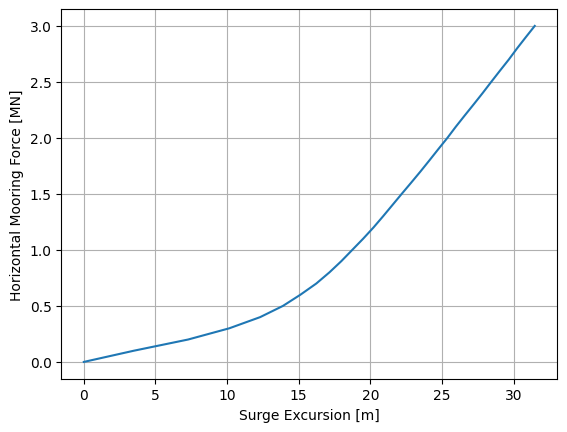

In [53]:
plt.figure()
# offset_pad = np.array([0, 3.49,  7.28, 10.15, 12.31, 13.9 , 15.12, 16.23, 17.15, 17.98,
#           18.74, 19.5 , 20.22, 20.89, 21.54, 22.19, 22.85, 23.5 , 24.13,
#           24.75, 25.38, 25.97, 26.59, 27.22, 27.84, 28.44, 29.05, 29.67,
#           30.25, 30.86, 31.48])
plt.plot(offset_pad, np.linspace(0, 3e6, Nsteps+1)/1e6)
plt.grid()
plt.xlabel('Surge Excursion [m]')
plt.ylabel('Horizontal Mooring Force [MN]')

Lastly the solutions are plotted.

In [54]:
# Pad a 0 to the beginning of each array
D_newl = np.insert(D_newl, 0, R_anchor)
step = np.insert(step,0, 10)
L_newl = np.insert(L_newl, 0,L_newl[0])
L_newr = np.insert(L_newr, 0,L_newl[0])
D_newr = np.insert(D_newr, 0,R_anchor)


In [55]:
# offset_pad = np.array([0, 3.49,  7.28, 10.15, 12.31, 13.9 , 15.12, 16.23, 17.15, 17.98,
#           18.74, 19.5 , 20.22, 20.89, 21.54, 22.19, 22.85, 23.5 , 24.13,
#           24.75, 25.38, 25.97, 26.59, 27.22, 27.84, 28.44, 29.05, 29.67,
#           30.25, 30.86, 31.48])

i = 0

# xl = np.zeros((len(offset_pad), nNode+1))
# xr = np.zeros((len(offset_pad), nNode+1))
# yl = np.zeros((len(offset_pad), nNode+1))
# yr = np.zeros((len(offset_pad), nNode+1))
# fxl = np.zeros(len(offset_pad))
# fxr = np.zeros(len(offset_pad))
# fyl = np.zeros(len(offset_pad))

flx = []
fly = []
frx = []
fry = []

EA = E_steel*A_anchor
m = (weight+rho_w)/g
# fyr = np.zeros(len(offset_pad))

for row in offset_pad:
    # All (last "safe" one interpolated)
    off_final = offset_pad[i] - 10**(0-2)/2

    # Left
    L_finall = L_newl[i] - step[i]/2
    D_finall = D_newl[i] - step[i]/2
    xl, yl, fxl, fyl = staticanchor(L_finall, D_finall, EA, m, g, TENSION_ONLY=1, initialplot=False, timeplot=False, finalplot=False)

    # Right
    L_finalr = L_newr[i] + step[i]/2
    D_finalr = D_newr[i] + step[i]/2
    xr, yr, fxr, fyr = staticanchor(L_finalr, D_finalr, EA, m, g, TENSION_ONLY=1, initialplot=False, timeplot=False, finalplot=False)
    
    sl = (yl[-1] - yl[-2])/(xl[-1] - xl[-2])
    sr = (yr[-1] - yr[-2])/(xr[-1] - xr[-2])
    
    pl = np.arctan(sl)
    pr = np.arctan(sr)
    flx.append(fxl)
    fly.append(fyl)
    frx.append(fxr)
    fry.append(fyr)

    i += 1
    



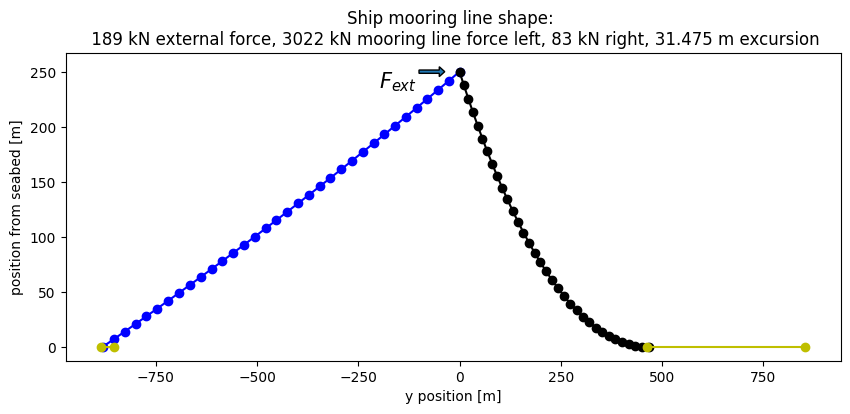

In [56]:

D = R_anchor
plt.figure(figsize=(10,4))
plt.plot([-i for i in xl], yl, '-ob')
plt.plot([-D, -D_newl[-1]],[0,0],'-oy')
plt.plot(xr, yr, '-ok')
plt.plot([D_newr[-1], D],[0,0],'-oy')

plt.xlabel("y position [m]")
plt.ylabel("position from seabed [m]")
str1 = f"Ship mooring line shape: \n {Fext/1000:.0f} kN external force, {fxl/1000:.0f} kN "
str2 = f"mooring line force left, {fxr/1000:.0f} kN right, {off_final:.3f} m excursion"
plt.title(str1+str2)
#plt.fill_between([-B/2+offset,-B/2+offset, B/2+offset, B/2+offset, -B/2+offset], [-5+H, 5+H, 5+H, -5+H, -5+H])
plt.arrow(-100, H, 50, 0, width=3)
plt.annotate("$F_{ext}$",(-200,-15+H),size=15);

In [57]:
step



array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10.])

array([[[  -301446.60422046,   -337379.97696724,   -397387.39134888,
           -470825.79506973,   -556149.09198733,   -645566.18232553,
           -734675.91644729,   -833331.58786685,   -927824.59341565,
          -1022160.27303207,  -1115123.41246619,  -1213381.04277708,
          -1310492.89336254,  -1403732.66190896,  -1496351.12914373,
          -1590714.92691488,  -1687995.05852086,  -1784986.08038156,
          -1879919.1421873 ,  -1974086.30735597,  -2070403.15388061,
          -2161091.87614698,  -2256823.13777638,  -2354484.90199056,
          -2450921.91636201,  -2544512.82574782,  -2639895.02460998,
          -2737049.1603971 ,  -2828101.84453703,  -2924017.01692269,
          -3021646.51348997]],

       [[ -2687887.6881004 ,  -3008292.26007346,  -3543356.14221022,
          -4198179.18029181,  -4958975.40782282,  -5756274.47459234,
          -6550832.95985101,  -7430509.03135846,  -8273068.15350561,
          -9114224.45860071,  -9943142.33139713, -10819269.21780724,
  

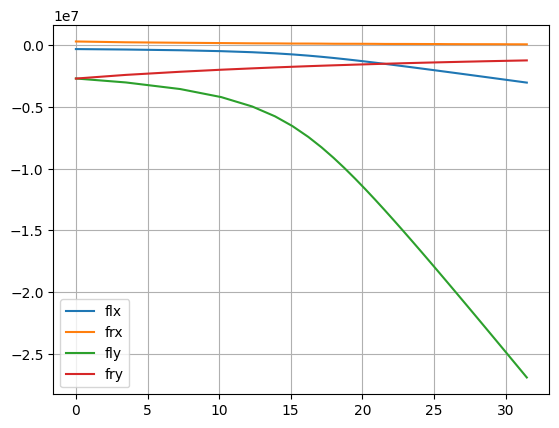

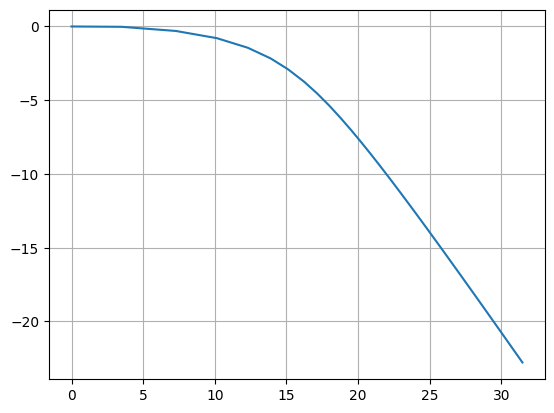

In [58]:
plt.figure()
plt.plot(offset_pad, -np.asarray(flx),label='flx')
plt.plot(offset_pad, np.asarray(frx),label='frx')
plt.plot(offset_pad, -np.asarray(fly),label='fly')
plt.plot(offset_pad, -np.asarray(fry),label='fry')
plt.grid()
plt.legend()

mooring_table = np.array([[-np.asarray(flx)], [-np.asarray(fly)], [np.asarray(frx)], [-np.asarray(fry)]])
# print(mooring_table)

plt.figure()
plt.plot(offset_pad, ((-np.asarray(fry)-np.asarray(fly))-(-np.asarray(fry[0])-np.asarray(fly[0])))/1e6)
plt.grid()

mooring_table

In [59]:
print(xr)


[0.0, 10.90042906379611, 21.994869861189255, 33.287455402519456, 44.782224290324294, 56.48308556851423, 68.39377882494068, 80.51782919205493, 92.85849692562319, 105.41872129875281, 118.20105863280494, 131.20761440344177, 144.43996951443052, 157.89910102884755, 171.58529789095206, 185.49807246438135, 199.63606905797937, 213.9969710109731, 228.57740806237464, 243.37286712481335, 258.3776082357974, 273.5845898133616, 288.9854063571758, 304.570242400878, 320.3278465763363, 336.24552938813866, 352.3091879339276, 368.50336012652156, 384.8113100342523, 401.2151447753697, 417.6959620354066, 434.2340258048433, 450.80896646476174, 467.3999999999994]


853.87
[853.87 857.35 861.14 864.01 866.17 867.76 868.98 870.09 871.01 871.84
 872.6  873.36 874.08 874.75 875.4  876.05 876.71 877.36 877.99 878.61
 879.24 879.83 880.45 881.08 881.7  882.3  882.91 883.53 884.11 884.72
 885.34]


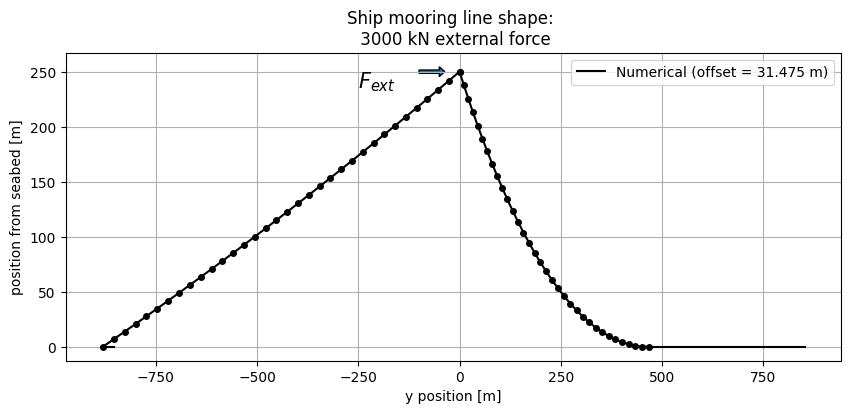

In [60]:
plt.figure(figsize=(10,4))
print(D)
print(D_newl)


# Numerical solution
plt.plot([-i for i in xl], yl, 'o-k', markersize=4)  # Smaller marker size
plt.plot([-D, -D_newl[-1]], [0, 0], '-k')
plt.plot(xr, yr, 'o-k', markersize=4)  # Smaller marker size
plt.plot([D_newr[-1], D], [0, 0], '-k', label=f"Numerical (offset = {off_final:.3f} m)")

# Catenary line original offset
# B = 0 # Makes ship-gap dissapear
# # Right side
# xmax = Fxr/w * np.arccosh(h*w/Fxr + 1)
# xtemp1 = np.linspace(0,xmax)
# xtemp2 = xtemp1[::-1]
# x1 = np.linspace(B/2+xpos, xmax+B/2+xpos)
# x2 = np.linspace(xmax+B/2+xpos,ymax)
# z1 = zline(Fxr,w,xtemp2,h)
# z1 = [i+H for i in z1]
# z2 = [-h for i in range(len(x2))]
# z2 = [i+H for i in z2]
# plt.plot(x1,z1, c="dodgerblue")
# plt.plot(x2,z2, c="dodgerblue")
# plt.plot(xmax+B/2+xpos,-h, c="dodgerblue")
# # Left side
# xmax = Fxl/w * np.arccosh(h*w/Fxl + 1)
# xtemp1 = np.linspace(0,xmax)
# xtemp2 = xtemp1[::-1]
# x1 = np.linspace(-B/2+xpos, -xmax-B/2+xpos)
# x2 = np.linspace(-xmax-B/2+xpos,-ymax)
# z1 = zline(Fxl,w,xtemp2,h)
# z1 = [i+H for i in z1]
# z2 = [-h for i in range(len(x2))]
# z2 = [i+H for i in z2]
# plt.plot(x1,z1, c="dodgerblue")
# plt.plot(x2,z2, c="dodgerblue", label=f"Catenary (offset = {catoff:.3f} m)")

# Catenary line numerical offset
# Right side
# plt.plot(D_newr,0,marker="o",color="orange")
# xmax = D_newr
# xtemp1 = np.linspace(0,xmax)
# xtemp2 = xtemp1[::-1]
# x1 = np.linspace(B/2+catoff, xmax+B/2+catoff)
# x2 = np.linspace(xmax+B/2+catoff,ymax)
# aaa = D_newr
# z1 = aaa*np.cosh((-x1+catoff)/aaa)-1.5*aaa
# z1 = [i+H for i in z1[::-1]]
# z1 = [i*(200/max(z1)) for i in z1] # Small visual correction
# z2 = [-h for i in range(len(x2))]
# z2 = [i+H for i in z2]
# plt.plot(x1,z1, c="orange")
# plt.plot(x2,z2, c="orange")
# # Left side
# plt.plot(-D_newl,0,marker="o",color="orange")
# xmax = D_newl
# xtemp1 = np.linspace(0,xmax)
# xtemp2 = xtemp1[::-1]
# x1 = np.linspace(-B/2+xpos, -xmax-B/2+xpos)
# x2 = np.linspace(-xmax-B/2+xpos,-ymax)
# z1 = zline(Fxl,w,xtemp2,h)
# z1 = [i+H for i in z1]
# z1 = [i*(200/max(z1)) for i in z1] # Small visual correction
# z2 = [-h for i in range(len(x2))]
# z2 = [i+H for i in z2]
# plt.plot(x1,z1, c="orange")
# plt.plot(x2,z2, c="orange", label=f"Catenary (offset = {off_final:.3f} m)")


plt.xlabel("y position [m]")
plt.ylabel("position from seabed [m]")
str1 = f"Ship mooring line shape: \n {F_d/1000:.0f} kN external force"
plt.title(str1)
plt.arrow(-100, H, 50, 0, width=3)
plt.annotate("$F_{ext}$",(-250,-15+H),size=15)
# plt.ylim((-20,220))
plt.grid()
plt.legend();

We can see that for larger offsets the results do differ quite a lot. This is mainly due to the diferent stiffness and mass influence assumptions in the two models. When comparing the line shape however we see a good accordance when equal offsets are imposed.